# 🎼 Adım 6 — Soft Voting Ensemble & Sigmoid Kalibrasyon

Bu notebook'ta iki son parçayı yerleştiriyoruz:

**Ensemble:** RF + ET + GB modellerini birleştir → tek bir güçlü karar

**Kalibrasyon:** Model çıktılarının gerçek olasılıkları temsil etmesini sağla

> **Finansal analoji:**  
> **Ensemble** = birden fazla analistin görüşünü ortala → tek analistin hatasını azalt  
> **Kalibrasyon** = modelin "%70 papilödem" demesi gerçekten %70 olasılığı yansıtıyor mu? Yoksa sistematik olarak mı sapıyor?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from mrmr import mrmr_classif
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Kütüphaneler hazır ✓')

Kütüphaneler hazır ✓


In [2]:
# ── Setup (önceki notebook'lardan) ──────────────────────────────────────────
normal = pd.read_csv('../data/normal_radiomics.csv')
papil  = pd.read_csv('../data/papilodem_radiomics.csv')
normal['label'] = 0; papil['label'] = 1
papil['PatientIndex'] = papil['PatientIndex'] + 1000  # Normal ve papilödem ID'leri örtüşüyor, offset ekle
df = pd.concat([normal, papil], ignore_index=True)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]

def hasta_bazinda_bol(df, test_ratio=0.20, val_ratio=0.10, random_state=42):
    rng = np.random.RandomState(random_state)
    hasta_etiket = df.groupby('PatientIndex')['label'].first()
    train_idx, val_idx, test_idx = [], [], []
    for sinif in [0, 1]:
        hastalar = hasta_etiket[hasta_etiket == sinif].index.tolist()
        rng.shuffle(hastalar)
        n = len(hastalar)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        test_idx  += hastalar[:n_test]
        val_idx   += hastalar[n_test:n_test + n_val]
        train_idx += hastalar[n_test + n_val:]
    return (df[df['PatientIndex'].isin(train_idx)].copy(),
            df[df['PatientIndex'].isin(val_idx)].copy(),
            df[df['PatientIndex'].isin(test_idx)].copy())

class RadyomikOnIsleme:
    def __init__(self, vt=0.01, ct=0.95):
        self.imputer = SimpleImputer(strategy='median')
        self.var_sel = VarianceThreshold(threshold=vt)
        self.scaler  = RobustScaler()
        self.feats_var = self.feats_corr = None
    def fit(self, X, fn):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.fit_transform(X)
        self.var_sel.fit(X)
        m = self.var_sel.get_support()
        self.feats_var = [f for f, v in zip(fn, m) if v]
        X = X[:, m]
        up = pd.DataFrame(X, columns=self.feats_var).corr().abs().where(
            np.triu(np.ones((len(self.feats_var),)*2), k=1).astype(bool))
        drop = [c for c in up.columns if any(up[c] > 0.95)]
        self.feats_corr = [f for f in self.feats_var if f not in drop]
        ki = [self.feats_var.index(f) for f in self.feats_corr]
        self.scaler.fit(X[:, ki]); return self
    def transform(self, X, fn):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.transform(X)
        X = pd.DataFrame(X, columns=fn)[self.feats_var].values
        X = pd.DataFrame(X, columns=self.feats_var)[self.feats_corr].values
        return self.scaler.transform(X)
    def fit_transform(self, X, fn):
        self.fit(X, fn); return self.transform(X, fn)

def optuna_en_iyi_params(X_tr, y_tr, groups, model_adi, n_trials=50):
    inner_cv = StratifiedGroupKFold(n_splits=3)
    def objective(trial):
        params = {}
        if model_adi in ['RF','ET']:
            Cls = RandomForestClassifier if model_adi=='RF' else ExtraTreesClassifier
            model = Cls(
                n_estimators=trial.suggest_int('n_estimators',50,500),
                max_depth=trial.suggest_int('max_depth',3,20),
                min_samples_split=trial.suggest_int('min_samples_split',2,20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10),
                max_features=trial.suggest_categorical('max_features',['sqrt','log2']),
                random_state=42, n_jobs=-1)
        else:
            model = GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators',50,300),
                max_depth=trial.suggest_int('max_depth',2,8),
                learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
                subsample=trial.suggest_float('subsample',0.5,1.0),
                min_samples_split=trial.suggest_int('min_samples_split',2,20),
                random_state=42)
        scores = [f1_score(y_tr[vi], model.fit(X_tr[ti], y_tr[ti]).predict(X_tr[vi]), average='macro')
                  for ti, vi in inner_cv.split(X_tr, y_tr, groups)]
        return np.mean(scores)
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

MRMR_K   = 10
N_SPLITS = 20
print('Setup hazır ✓')

Setup hazır ✓


---
## Bölüm A — Soft Voting Ensemble

**Soft Voting nedir?**  
Her model için sınıf olasılıkları hesaplanır, sonra **ortalamaları** alınır.  
En yüksek ortalama olasılığa sahip sınıf tahmin edilir.

Hard voting'den farkı: Hard voting sadece "0 mı 1 mi" oylama yapar.  
Soft voting ise "%60 papilödem", "%75 papilödem", "%80 papilödem" → ortalama %71.7 → papilödem der.

**Neden daha iyi?** RF yüksek güvenle yanlışsa ET'nin daha düşük güveni onu dengeleyebilir.

---
## Bölüm B — Sigmoid Kalibrasyon

**Problem:** Random Forest gibi modeller olasılık tahminlerinde sistematik hatalar yapar.  
Örneğin, modelin "%90 papilödem" dediği durumların gerçekte sadece %70'i papilödem olabilir.

**Sigmoid kalibrasyon:** Modelin ham olasılık çıktılarını gerçek olasılıklara eşlemek için  
bir sigmoid fonksiyonu fit eder. Bu fit **sadece train verisinde** yapılır.

**Brier Score:** Kalibrasyon kalitesini ölçer. 0 = mükemmel, 1 = berbat.  
**ECE (Expected Calibration Error):** Tahmin edilen olasılık ile gerçek oran arasındaki ortalama fark.

In [3]:
def ece_hesapla(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — 10 bin."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * abs(acc - conf)
    return ece / len(y_true)

def hasta_seviyesi_tahmin(patient_ids, y_prob, y_true, strateji='mean'):
    """Sample-level olasılıkları hasta bazında agregasyon."""
    hasta_df = pd.DataFrame({
        'patient': patient_ids,
        'prob'   : y_prob,
        'true'   : y_true
    })
    if strateji == 'mean':
        hasta_ozet = hasta_df.groupby('patient').agg(
            prob_agg=('prob', 'mean'),
            true_label=('true', 'first')
        ).reset_index()
    hasta_ozet['pred'] = (hasta_ozet['prob_agg'] >= 0.5).astype(int)
    return hasta_ozet

print('Yardımcı fonksiyonlar hazır ✓')

Yardımcı fonksiyonlar hazır ✓


In [4]:
# ── ANA DÖNGÜ: 20 split × ensemble + kalibrasyon ────────────────────────────
import time

tum_sonuclar = []
baslangic = time.time()

for split_no in range(N_SPLITS):
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no*7+42)

    pipe = RadyomikOnIsleme()
    X_tr = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_te = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr = train_df['label'].values
    y_te = test_df['label'].values
    groups = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr

    # MRMR
    feats = mrmr_classif(X=pd.DataFrame(X_tr, columns=proc_cols),
                         y=pd.Series(y_tr), K=MRMR_K)
    X_tr_m = pd.DataFrame(X_tr, columns=proc_cols)[feats].values
    X_te_m = pd.DataFrame(X_te, columns=proc_cols)[feats].values

    # Optuna → en iyi parametreler
    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in ['RF','ET','GB']}

    # Modelleri kur
    rf = RandomForestClassifier(**params['RF'], random_state=42, n_jobs=-1)
    et = ExtraTreesClassifier(**params['ET'], random_state=42, n_jobs=-1)
    gb = GradientBoostingClassifier(**params['GB'], random_state=42)

    # Soft Voting Ensemble
    ensemble = VotingClassifier(
        estimators=[('RF', rf), ('ET', et), ('GB', gb)],
        voting='soft'
    )
    ensemble.fit(X_tr_m, y_tr)

    # Sigmoid Kalibrasyon — cv=3 cross-val üzerinde fit (cv='prefit' eski sklearn'de kaldırıldı)
    cal_ensemble = CalibratedClassifierCV(ensemble, method='sigmoid', cv=3)
    cal_ensemble.fit(X_tr_m, y_tr)

    # Test seti tahminleri
    y_prob_raw = ensemble.predict_proba(X_te_m)[:, 1]
    y_prob_cal = cal_ensemble.predict_proba(X_te_m)[:, 1]
    y_pred_cal = (y_prob_cal >= 0.5).astype(int)

    # Metrik hesaplama fonksiyonu
    def metrikleri_hesapla(y_true, y_pred, y_prob, etiket):
        has_both = len(np.unique(y_true)) > 1
        return {
            'split'    : split_no,
            'seviye'   : etiket,
            'accuracy' : round(accuracy_score(y_true, y_pred), 4),
            'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
            'recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
            'macro_f1' : round(f1_score(y_true, y_pred, average='macro'), 4),
            'roc_auc'  : round(roc_auc_score(y_true, y_prob), 4) if has_both else np.nan,
            'pr_auc'   : round(average_precision_score(y_true, y_prob), 4) if has_both else np.nan,
            'brier'    : round(brier_score_loss(y_true, y_prob), 4),
            'ece_10'   : round(ece_hesapla(y_true, y_prob), 4)
        }

    # Sample-level metrikler
    sample_row = metrikleri_hesapla(y_te, y_pred_cal, y_prob_cal, 'sample')
    tum_sonuclar.append(sample_row)

    # Hasta-level metrikler — HER ZAMAN ekle, tek sınıflı durumda roc/pr NaN olur
    hasta_df_test = hasta_seviyesi_tahmin(
        test_df['PatientIndex'].values, y_prob_cal, y_te
    )
    patient_row = metrikleri_hesapla(
        hasta_df_test['true_label'].values,
        hasta_df_test['pred'].values,
        hasta_df_test['prob_agg'].values,
        'patient'
    )
    tum_sonuclar.append(patient_row)

    print(f'Split {split_no+1:2d}/20 — '
          f'Sample F1: {sample_row["macro_f1"]:.4f} | '
          f'Patient F1: {patient_row["macro_f1"]:.4f} | '
          f'Süre: {(time.time()-baslangic)/60:.1f}dk')

sonuc_df = pd.DataFrame(tum_sonuclar)
sonuc_df.to_csv('../results/ensemble_test_sonuclari.csv', index=False)
print(f'\n✓ Tamamlandı. Toplam süre: {(time.time()-baslangic)/60:.1f} dk')
print(f'Toplam satır: {len(sonuc_df)} (sample: {(sonuc_df.seviye=="sample").sum()}, '
      f'patient: {(sonuc_df.seviye=="patient").sum()})')


100%|██████████| 10/10 [00:00<00:00, 71.10it/s]


Split  1/20 — Sample F1: 0.8595 | Patient F1: 0.9023 | Süre: 1.2dk


100%|██████████| 10/10 [00:00<00:00, 72.86it/s]


Split  2/20 — Sample F1: 0.9417 | Patient F1: 1.0000 | Süre: 2.4dk


100%|██████████| 10/10 [00:00<00:00, 73.35it/s]


...

Split 18/20 — Sample F1: 0.9384 | Patient F1: 1.0000 | Süre: 19.3dk


100%|██████████| 10/10 [00:00<00:00, 73.95it/s]


Split 19/20 — Sample F1: 0.9266 | Patient F1: 1.0000 | Süre: 20.4dk


100%|██████████| 10/10 [00:00<00:00, 72.00it/s]


Split 20/20 — Sample F1: 0.7737 | Patient F1: 0.7833 | Süre: 21.5dk

✓ Tamamlandı. Toplam süre: 21.5 dk
Toplam satır: 40 (sample: 20, patient: 20)


In [5]:
# Özet tablo
metrикler = ['accuracy','precision','recall','macro_f1','roc_auc','pr_auc','brier','ece_10']

for seviye in ['sample', 'patient']:
    alt = sonuc_df[sonuc_df.seviye == seviye]
    ozet = alt[metrикler].agg(['mean','std']).T.round(4)
    ozet.columns = ['Ortalama', 'Std']
    print(f'\n=== {seviye.upper()}-LEVEL METRİKLER (20 split) ===')
    display(ozet)


=== SAMPLE-LEVEL METRİKLER (20 split) ===


,Ortalama,Std
accuracy,0.8937,0.0640
precision,0.8892,0.0874
recall,0.7455,0.1971
macro_f1,0.8629,0.0928
roc_auc,0.9226,0.0839
pr_auc,0.8964,0.1095
brier,0.0861,0.0495
ece_10,0.1029,0.0385



=== PATIENT-LEVEL METRİKLER (20 split) ===


,Ortalama,Std
accuracy,0.9269,0.0682
precision,1.0000,0.0000
recall,0.7625,0.2218
macro_f1,0.8990,0.1021
roc_auc,0.9333,0.1049
pr_auc,0.9262,0.1165
brier,0.0725,0.0476
ece_10,0.1531,0.0399


100%|██████████| 10/10 [00:00<00:00, 30.48it/s]


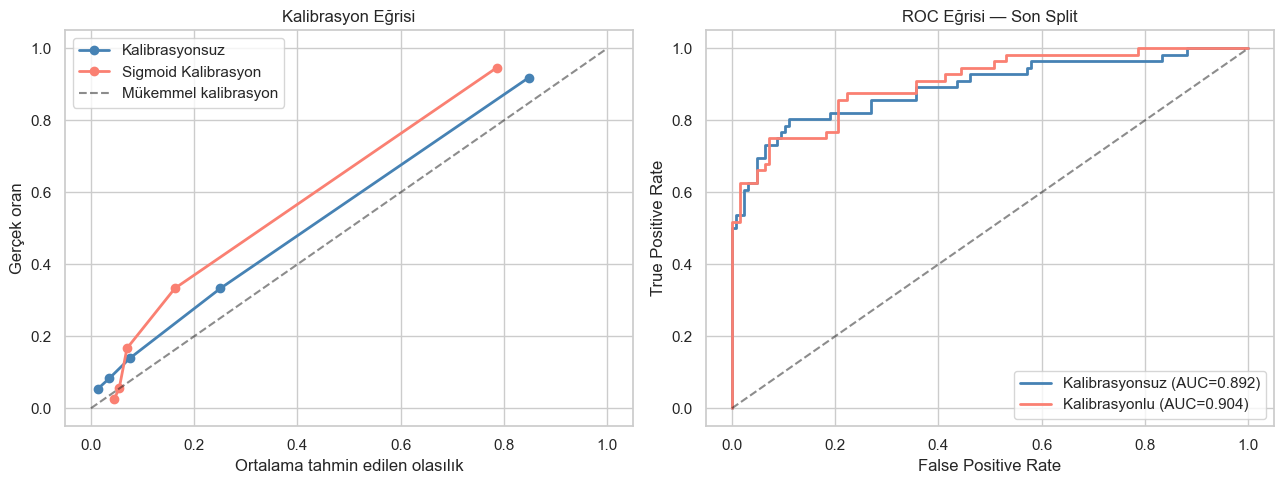

Kalibrasyonsuz Brier: 0.1058
Kalibrasyonlu  Brier: 0.1158
(Brier düştüyse kalibrasyon işe yaradı ✓)


In [6]:
# Kalibrasyon etkisini göster — son split üzerinde
train_df_s, _, test_df_s = hasta_bazinda_bol(df, random_state=19*7+42)
pipe_s = RadyomikOnIsleme()
X_tr_s = pipe_s.fit_transform(train_df_s[feature_cols].values, feature_cols)
X_te_s = pipe_s.transform(test_df_s[feature_cols].values, feature_cols)
y_tr_s = train_df_s['label'].values
y_te_s = test_df_s['label'].values
feats_s = mrmr_classif(X=pd.DataFrame(X_tr_s, columns=pipe_s.feats_corr),
                        y=pd.Series(y_tr_s), K=MRMR_K)
X_tr_ms = pd.DataFrame(X_tr_s, columns=pipe_s.feats_corr)[feats_s].values
X_te_ms = pd.DataFrame(X_te_s, columns=pipe_s.feats_corr)[feats_s].values

# Kalibrasyonsuz ensemble
ens_s = VotingClassifier(estimators=[
    ('RF', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('ET', ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('GB', GradientBoostingClassifier(n_estimators=100, random_state=42))
], voting='soft')
ens_s.fit(X_tr_ms, y_tr_s)
prob_raw_s = ens_s.predict_proba(X_te_ms)[:, 1]

# Kalibrasyonlu
cal_s = CalibratedClassifierCV(ens_s, method='sigmoid', cv=3)
cal_s.fit(X_tr_ms, y_tr_s)
prob_cal_s = cal_s.predict_proba(X_te_ms)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kalibrasyon eğrisi
for prob, isim, renk in [(prob_raw_s,'Kalibrasyonsuz','steelblue'),
                          (prob_cal_s,'Sigmoid Kalibrasyon','salmon')]:
    if len(np.unique(y_te_s)) > 1:
        frac_pos, mean_pred = calibration_curve(y_te_s, prob, n_bins=5, strategy='quantile')
        axes[0].plot(mean_pred, frac_pos, marker='o', label=isim, color=renk, linewidth=2)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Mükemmel kalibrasyon')
axes[0].set_xlabel('Ortalama tahmin edilen olasılık')
axes[0].set_ylabel('Gerçek oran')
axes[0].set_title('Kalibrasyon Eğrisi')
axes[0].legend()

# ROC eğrisi
if len(np.unique(y_te_s)) > 1:
    for prob, isim, renk in [(prob_raw_s,'Kalibrasyonsuz','steelblue'),
                              (prob_cal_s,'Kalibrasyonlu','salmon')]:
        fpr, tpr, _ = roc_curve(y_te_s, prob)
        auc = roc_auc_score(y_te_s, prob)
        axes[1].plot(fpr, tpr, label=f'{isim} (AUC={auc:.3f})', color=renk, linewidth=2)
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Eğrisi — Son Split')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig_kalibrasyon_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Kalibrasyonsuz Brier: {brier_score_loss(y_te_s, prob_raw_s):.4f}')
print(f'Kalibrasyonlu  Brier: {brier_score_loss(y_te_s, prob_cal_s):.4f}')
print('(Brier düştüyse kalibrasyon işe yaradı ✓)')

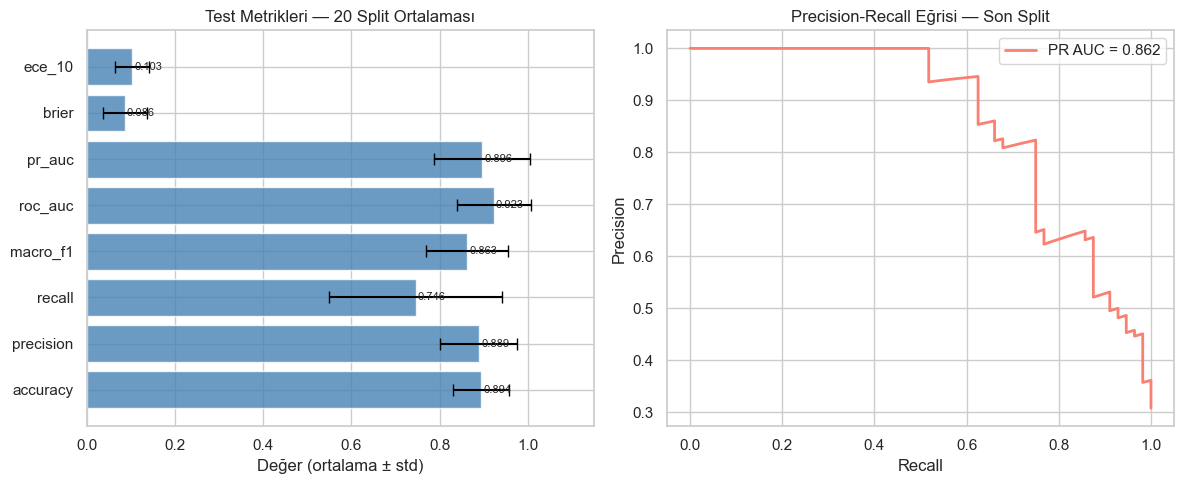

In [7]:
# Confusion matrix — 20 split ortalaması
sample_df = sonuc_df[sonuc_df.seviye == 'sample']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrik_cols = ['accuracy','precision','recall','macro_f1','roc_auc','pr_auc','brier','ece_10']
ort = sample_df[metrik_cols].mean().round(4)
std = sample_df[metrik_cols].std().round(4)

bars = axes[0].barh(metrik_cols, ort.values, color='steelblue', alpha=0.8)
axes[0].errorbar(ort.values, metrik_cols, xerr=std.values,
                 fmt='none', color='black', capsize=4)
for bar, v in zip(bars, ort.values):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)
axes[0].set_xlim(0, 1.15)
axes[0].set_title('Test Metrikleri — 20 Split Ortalaması')
axes[0].set_xlabel('Değer (ortalama ± std)')

# PR eğrisi — son split
if len(np.unique(y_te_s)) > 1:
    prec, rec, _ = precision_recall_curve(y_te_s, prob_cal_s)
    pr_auc_val = average_precision_score(y_te_s, prob_cal_s)
    axes[1].plot(rec, prec, color='salmon', linewidth=2,
                 label=f'PR AUC = {pr_auc_val:.3f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Eğrisi — Son Split')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig_metrikler_pr.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
sample_ozet = sonuc_df[sonuc_df.seviye=='sample'][metrik_cols].agg(['mean','std']).T.round(4)
patient_ozet = sonuc_df[sonuc_df.seviye=='patient'][metrik_cols].agg(['mean','std']).T.round(4)
sample_ozet.columns  = ['Sample Mean', 'Sample Std']
patient_ozet.columns = ['Patient Mean', 'Patient Std']

print('=' * 60)
print('FİNAL SONUÇ TABLOSU — Soft Voting Ensemble + Sigmoid Kalibrasyon')
print('=' * 60)
display(pd.concat([sample_ozet, patient_ozet], axis=1))
print('\nSıradaki adım → 07_istatistiksel_analiz.ipynb')

FİNAL SONUÇ TABLOSU — Soft Voting Ensemble + Sigmoid Kalibrasyon


,Sample Mean,Sample Std,Patient Mean,Patient Std
accuracy,0.8937,0.0640,0.9269,0.0682
precision,0.8892,0.0874,1.0000,0.0000
recall,0.7455,0.1971,0.7625,0.2218
macro_f1,0.8629,0.0928,0.8990,0.1021
roc_auc,0.9226,0.0839,0.9333,0.1049
pr_auc,0.8964,0.1095,0.9262,0.1165
brier,0.0861,0.0495,0.0725,0.0476
ece_10,0.1029,0.0385,0.1531,0.0399



Sıradaki adım → 07_istatistiksel_analiz.ipynb
